In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("Titanic.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Fill missing age with mean
df['Age'] =df['Age'].fillna(df['Age'].mean())

In [7]:

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# Drop cabin coloumn
df.drop('Cabin', axis=1, errors='ignore', inplace=True)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [10]:
# Survival rate by Age Group.
# Age groups banana
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# Survival rate by age group
survival_rate = df.groupby('Age_Group', observed=True)['Survived'].mean() * 100

print(survival_rate)

Age_Group
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


In [12]:
# Survival rate by Embarkation Port
survival_rate = df.groupby('Embarked')['Survived'].mean() * 100

print(survival_rate)

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


In [13]:
# Family Size feature create karein
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Survival rate calculate karein
family_survival = (
    df.groupby('FamilySize')['Survived']
      .mean()
      .mul(100)
      .round(2)
)

print(family_survival)

FamilySize
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64


In [16]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(Age, bins=20, color='skyblue', edgecolor='black')

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

NameError: name 'Age' is not defined

<Figure size 800x500 with 0 Axes>

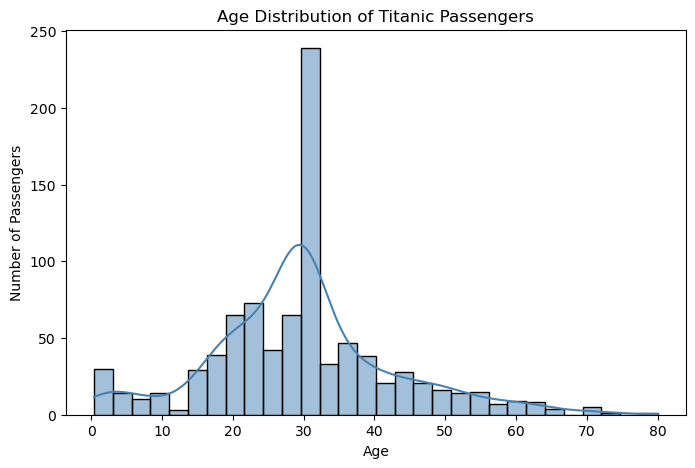

In [17]:

# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

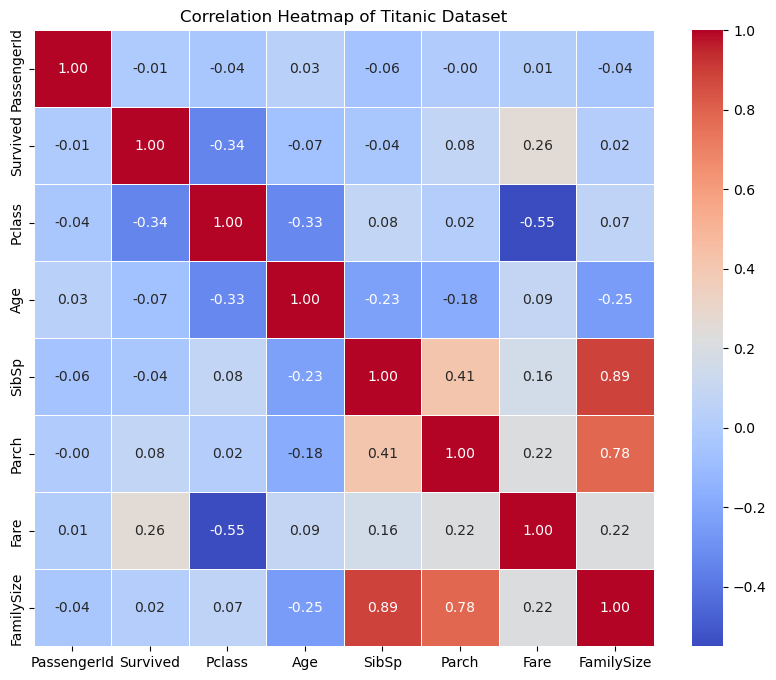

In [18]:
# Heatmap of correlations
#Numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Titanic Dataset')
plt.show()

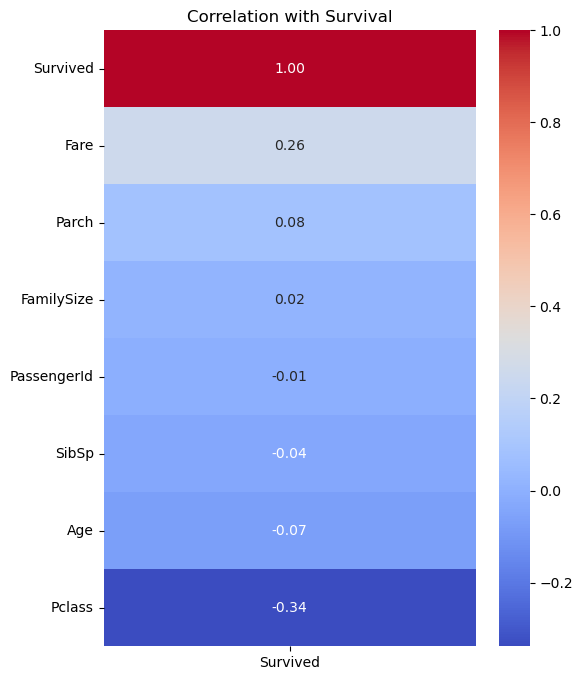

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(6, 8))
sns.heatmap(
    numeric_df.corr()[['Survived']].sort_values(by='Survived', ascending=False),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation with Survival')
plt.show()

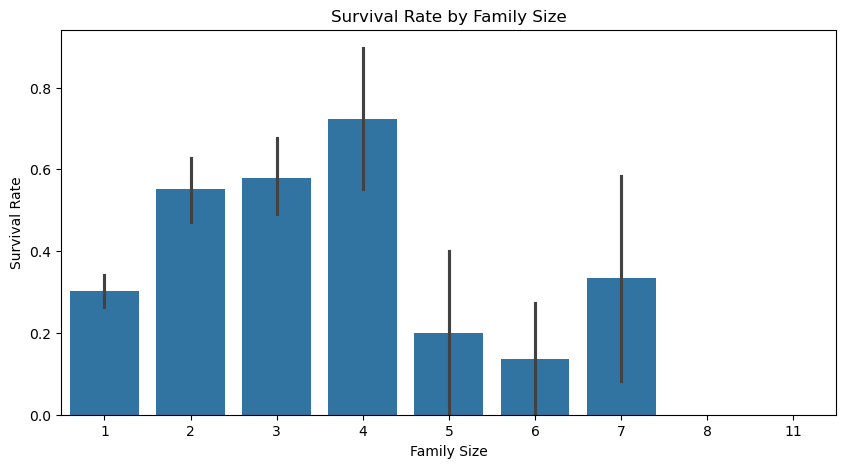

In [21]:
#Survival by family size (bar plot).
# Create Family Size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Bar plot
plt.figure(figsize=(10,5))
sns.barplot(x='FamilySize', y='Survived', data=df)

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()